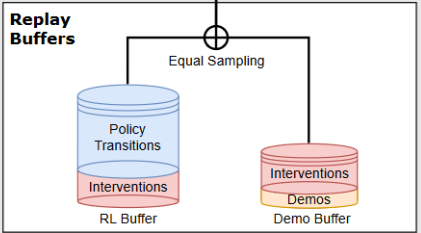

去掉interventions的数据，将demo buffer的数据用专家数据来替代，专家数据使用一个PPO网络来近似替代


# 专家数据生成

In [ ]:
import gymnasium as gym
import torch
import torch.nn.functional as F
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import random
import rl_utils
from torch.distributions import Normal # 正态分布（高斯分布）


class PolicyNetContinuous(torch.nn.Module):
    def __init__(self, state_dim, hidden_dim, action_dim):
        super(PolicyNetContinuous, self).__init__()
        self.fc1 = torch.nn.Linear(state_dim, hidden_dim)
        self.fc_mu = torch.nn.Linear(hidden_dim, action_dim)
        self.fc_std = torch.nn.Linear(hidden_dim, action_dim)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        mu = 2.0 * torch.tanh(self.fc_mu(x)) # 通过tanh函数将动作均值限制在[-2, 2]范围内
        std = F.softplus(self.fc_std(x)) # 计算标准差
        return mu, std


class ValueNet(torch.nn.Module):
    def __init__(self, state_dim, hidden_dim):
        super(ValueNet, self).__init__()
        self.fc1 = torch.nn.Linear(state_dim, hidden_dim)
        self.fc2 = torch.nn.Linear(hidden_dim, 1)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        return self.fc2(x)


class PPOContinuous:
    """处理连续动作"""
    def __init__(self, state_dim, hidden_dim, action_dim, actor_lr, critic_lr,
                lmbda, epochs, eps, gamma, device):
        self.actor = PolicyNetContinuous(state_dim, hidden_dim, action_dim).to(device)
        self.critic = ValueNet(state_dim, hidden_dim).to(device)

        self.actor_optimizer = torch.optim.Adam(self.actor.parameters(), lr=actor_lr)
        self.critic_optimizer = torch.optim.Adam(self.critic.parameters(), lr=critic_lr)

        self.gamma = gamma
        self.lmbda = lmbda
        self.epochs = epochs # 一条trajectory更新的轮数
        self.eps = eps # 截断参数
        self.device = device

    def take_action(self, state):
        state = torch.tensor([state], dtype=torch.float).to(self.device)
        mu, sigma = self.actor(state)
        action_dist = torch.distributions.Normal(mu, sigma)
        action = action_dist.sample()
        return [action.item()]

    def update(self, transition_dict):
        states = torch.tensor(transition_dict['states'], dtype=torch.float).to(self.device)
        actions = torch.tensor(transition_dict['actions']).view(-1, 1).to(self.device)
        rewards = torch.tensor(transition_dict['rewards'], dtype=torch.float).view(-1, 1).to(self.device)
        next_states = torch.tensor(transition_dict['next_states'], dtype=torch.float).to(self.device)
        dones = torch.tensor(transition_dict['dones'], dtype=torch.float).view(-1, 1).to(self.device)

        rewards = (rewards + 8.0) / 8.0 # 对奖励进行归一化，防止数值过大导致训练不稳定
        # TD target
        td_target = rewards + self.gamma * self.critic(next_states) * (1 - dones)
        
        # TD error
        td_error = td_target - self.critic(states)
        
        # 优势估计
        advantage = rl_utils.compute_advantage(self.gamma, self.lmbda, td_error.cpu()).to(self.device)
        
        # 根据实际选择的动作计算旧策略的log动作分布
        mu, std = self.actor(states)
        action_dists = torch.distributions.Normal(mu.detach(), std.detach())
        old_log_probs = action_dists.log_prob(actions)

        # 用一条trajectory多次更新策略和价值网络（importance sampling）
        for _ in range(self.epochs):
            mu, std = self.actor(states)
            action_dists = torch.distributions.Normal(mu, std)
            log_probs = action_dists.log_prob(actions)
            ratio = torch.exp(log_probs - old_log_probs)

            surr1 = ratio * advantage
            surr2 = torch.clamp(ratio, 1 - self.eps, 1 + self.eps) * advantage # 截断

            actor_loss = torch.mean(-torch.min(surr1, surr2))
            critic_loss = torch.mean(F.mse_loss(self.critic(states), td_target.detach()))

            self.actor_optimizer.zero_grad()
            actor_loss.backward()
            self.actor_optimizer.step()

            self.critic_optimizer.zero_grad()
            critic_loss.backward()
            self.critic_optimizer.step()


# 创建连续动作环境
actor_lr = 1e-4
critic_lr = 5e-3
num_episodes = 2000
hidden_dim = 128
gamma = 0.9
lmbda = 0.9
epochs = 10
eps = 0.2
device = torch.device("cuda") if torch.cuda.is_available() else torch.device(
    "cpu")

env_name = 'Pendulum-v1'
env = gym.make(env_name)

env.reset(seed=0)
torch.manual_seed(0)

state_dim = env.observation_space.shape[0]
action_dim = env.action_space.shape[0]  # 连续动作空间

ppo_agent = PPOContinuous(state_dim, hidden_dim, action_dim, actor_lr, critic_lr,
                      lmbda, epochs, eps, gamma, device)

return_list = rl_utils.train_on_policy_agent(env, ppo_agent, num_episodes)

Iteration 0:   0%|          | 0/200 [00:00<?, ?it/s]C:\Users\Administrator\AppData\Local\Temp\ipykernel_3288\171592607.py:54: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at C:\cb\pytorch_1000000000000\work\torch\csrc\utils\tensor_new.cpp:281.)
  state = torch.tensor([state], dtype=torch.float).to(self.device)
Iteration 9: 100%|██████████| 200/200 [00:27<00:00,  7.35it/s, episode=2000, return=-377.328]


In [11]:
def sample_expert_data(n_episode):
    # 使用字典或多个列表来存储完整的 Transition
    states = []
    actions = []
    rewards = []
    next_states = []
    dones = []
    
    for episode in range(n_episode):
        state, _ = env.reset()
        done = False
        while not done:
            action = ppo_agent.take_action(state)
            next_state, reward, terminated, truncated, _  = env.step(action)
            is_done = terminated or truncated
            
            # 将完整的五元组存入列表
            states.append(state)
            actions.append(action)
            rewards.append(reward)
            next_states.append(next_state)
            dones.append(is_done)
            
            # 更新状态进入下一步
            state = next_state
            done = is_done
            
    return (np.array(states), np.array(actions), 
            np.array(rewards), np.array(next_states), np.array(dones))
    
env.reset(seed=0)
torch.manual_seed(0)
random.seed(0)

n_episode = 1
# 获取完整的专家轨迹数据
expert_s, expert_a, expert_r, expert_next_s, expert_done = sample_expert_data(n_episode)

n_samples = 30  # 论文中也提到使用 30 个专家演示数据来初始化离线数据集

# 随机采样 30 个索引
random_index = random.sample(range(expert_s.shape[0]), n_samples)

# 根据相同的索引，把对应的 s, a, r, s', done 一起提取出来
sampled_s = expert_s[random_index]
sampled_a = expert_a[random_index]
sampled_r = expert_r[random_index]
sampled_next_s = expert_next_s[random_index]
sampled_done = expert_done[random_index]

# SAC网络

In [3]:
class PolicyNetContinuous(torch.nn.Module):
    def __init__(self, state_dim, hidden_dim, action_dim, action_bound):
        super(PolicyNetContinuous, self).__init__()
        self.fc1 = torch.nn.Linear(state_dim, hidden_dim)
        self.fc_mu = torch.nn.Linear(hidden_dim, action_dim)
        self.fc_std = torch.nn.Linear(hidden_dim, action_dim)
        self.action_bound = action_bound

    def forward(self, x):
        x = F.relu(self.fc1(x))
        mu = self.fc_mu(x)
        std = F.softplus(self.fc_std(x)) + 1e-7  # Ensure std is positive
        dist = Normal(mu, std)
        normal_sample = dist.rsample()  # Reparameterization trick
        log_prob = dist.log_prob(normal_sample)
        action = torch.tanh(normal_sample) # 将动作限制在[-1, 1]范围内
        # 计算对应概率密度
        # 因为对高斯分布施加了非线性的tanh变换，所以需要减去变换函数(tanh)导数的对数
        # 最终才能得到正确的log_prob
        log_prob = log_prob - torch.log(1 - action.pow(2) + 1e-7)
        action = action * self.action_bound
        return action, log_prob


class QValueNetContinuous(torch.nn.Module):
    def __init__(self, state_dim, hidden_dim, action_dim):
        super(QValueNetContinuous, self).__init__()
        self.fc1 = torch.nn.Linear(state_dim + action_dim, hidden_dim)
        self.fc2 = torch.nn.Linear(hidden_dim, hidden_dim)
        self.fc_out = torch.nn.Linear(hidden_dim, 1)

    def forward(self, state, action):
        x = torch.cat([state, action], dim=1)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        q_value = self.fc_out(x)
        return q_value
    

class SACContinuous:
    """处理连续动作的SAC算法"""
    def __init__(self, state_dim, hidden_dim, action_dim, action_bound,
                 actor_lr, critic_lr, alpha_lr, target_entropy, tau, gamma, device):
        self.actor = PolicyNetContinuous(state_dim, hidden_dim, action_dim, action_bound).to(device)
        self.critic_1 = QValueNetContinuous(state_dim, hidden_dim, action_dim).to(device)
        self.critic_2 = QValueNetContinuous(state_dim, hidden_dim, action_dim).to(device)
        self.target_critic_1 = QValueNetContinuous(state_dim, hidden_dim, action_dim).to(device)
        self.target_critic_2 = QValueNetContinuous(state_dim, hidden_dim, action_dim).to(device)

        # 令目标Q网络的初始权重与当前Q网络相同
        self.target_critic_1.load_state_dict(self.critic_1.state_dict())
        self.target_critic_2.load_state_dict(self.critic_2.state_dict())    

        self.actor_optimizer = torch.optim.Adam(self.actor.parameters(), lr=actor_lr)
        self.critic_1_optimizer = torch.optim.Adam(self.critic_1.parameters(), lr=critic_lr)
        self.critic_2_optimizer = torch.optim.Adam(self.critic_2.parameters(), lr=critic_lr)
        
        # 使用自动调整的温度参数alpha来平衡探索和利用
        self.log_alpha = torch.tensor(np.log(0.01), dtype=torch.float)
        self.log_alpha.requires_grad = True
        self.alpha_optimizer = torch.optim.Adam([self.log_alpha], lr=alpha_lr)

        self.target_entropy = target_entropy
        self.tau = tau
        self.gamma = gamma
        self.device = device


    # 计算目标Q值
    def calc_target(self, rewards, next_states, dones):
        next_actions, log_probs = self.actor(next_states)
        entropy = -log_probs  # 计算熵
        q1_value = self.target_critic_1(next_states, next_actions)
        q2_value = self.target_critic_2(next_states, next_actions)
        next_value = torch.min(q1_value, q2_value) + self.log_alpha.exp() * entropy
        td_target = rewards + self.gamma * next_value * (1 - dones) # dones是布尔值，表示是否结束，如果结束了就不考虑下一个状态的价值了
        return td_target


    def take_action(self, state):
        state = torch.tensor([state], dtype=torch.float).to(self.device)
        action = self.actor(state)[0]
        return [action.item()]
    

    def soft_update(self, net, target_net):
        for param_target, param in zip(target_net.parameters(), net.parameters()):
            param_target.data.copy_(param_target.data * (1.0 - self.tau) + param.data * self.tau)
    

    def update(self, transition_dict):
        states = torch.tensor(transition_dict['states'], dtype=torch.float).to(self.device)
        actions = torch.tensor(transition_dict['actions'], dtype=torch.float).view(-1, 1).to(self.device)
        rewards = torch.tensor(transition_dict['rewards'], dtype=torch.float).view(-1, 1).to(self.device)
        next_states = torch.tensor(transition_dict['next_states'], dtype=torch.float).to(self.device)
        dones = torch.tensor(transition_dict['dones'], dtype=torch.float).view(-1, 1).to(self.device)

        # 对奖励进行归一化，原本CartPole的奖励是+1，episode结束时是0或-1，这样处理后奖励范围大致在[0, 1]之间，有利于训练稳定性
        rewards = (rewards + 8.0) / 8.0 

        # 更新两个Q网络
        td_target = self.calc_target(rewards, next_states, dones)
        critic_1_loss = torch.mean(
            F.mse_loss(self.critic_1(states, actions), td_target.detach())
        )
        critic_2_loss = torch.mean(
            F.mse_loss(self.critic_2(states, actions), td_target.detach())
        )

        self.critic_1_optimizer.zero_grad()
        critic_1_loss.backward()
        self.critic_1_optimizer.step()

        self.critic_2_optimizer.zero_grad()
        critic_2_loss.backward()
        self.critic_2_optimizer.step()

        # 更新策略网络
        new_actions, log_probs = self.actor(states)
        entropy = -log_probs  # 计算熵
        q1_value = self.critic_1(states, new_actions)
        q2_value = self.critic_2(states, new_actions)
        actor_loss = torch.mean(-self.log_alpha.exp() * entropy - torch.min(q1_value, q2_value))

        self.actor_optimizer.zero_grad()
        actor_loss.backward()
        self.actor_optimizer.step()

        # 更新alpha值
        alpha_loss = torch.mean(self.log_alpha.exp() * (entropy - self.target_entropy).detach())
        
        self.alpha_optimizer.zero_grad()
        alpha_loss.backward()
        self.alpha_optimizer.step()

        self.soft_update(self.critic_1, self.target_critic_1)
        self.soft_update(self.critic_2, self.target_critic_2)

# 采样池

In [7]:
import collections
import random
import numpy as np

class ReplayBuffer_EqualSampling:
    def __init__(self, rl_capacity, demo_capacity=None):
        """
        初始化双重经验回放池
        :param rl_capacity: RL Buffer (Policy Transitions) 的容量
        :param demo_capacity: Demo Buffer (Expert Data) 的容量。如果不指定，则默认与 rl_capacity 相同
        """
        if demo_capacity is None:
            demo_capacity = rl_capacity
            
        self.rl_buffer = collections.deque(maxlen=rl_capacity)
        self.demo_buffer = collections.deque(maxlen=demo_capacity) 

    def add(self, state, action, reward, next_state, done): 
        """智能体交互时调用的方法，数据存入 RL Buffer"""
        self.rl_buffer.append((state, action, reward, next_state, done)) 
        
    def add_demo(self, state, action, reward, next_state, done):
        """添加专家数据的方法，数据存入 Demo Buffer"""
        self.demo_buffer.append((state, action, reward, next_state, done))

    def sample(self, batch_size): 
        """
        Equal Sampling 核心逻辑：各抽 50%
        """
        demo_batch_size = batch_size // 2
        rl_batch_size = batch_size - demo_batch_size

        # 安全检查 1：确保 RL buffer 数据够抽（通常智能体会先随机走几步预热）
        if len(self.rl_buffer) < rl_batch_size:
            raise ValueError(f"RL buffer 数据量不足! 当前: {len(self.rl_buffer)}, 需要: {rl_batch_size}")
            
        # 安全检查 2：确保 Demo buffer 里面至少有数据
        if len(self.demo_buffer) == 0:
            raise ValueError("Demo buffer 为空！请在开始训练前先调用 add_demo() 填入那 30 条专家数据。")

        # 1. 从 RL Buffer 采样 (无放回采样)
        transitions_rl = random.sample(self.rl_buffer, rl_batch_size)

        # 2. 从 Demo Buffer 采样 (使用 random.choices 进行有放回采样)
        # 这样即使只有 30 条数据，也可以顺利抽出 64、128 甚至更多的数据（会有重复）
        transitions_demo = random.choices(list(self.demo_buffer), k=demo_batch_size)

        # 将两部分数据合并
        transitions = transitions_rl + transitions_demo
        
        # 打乱顺序，防止网络产生偏置
        random.shuffle(transitions)

        # 解包重组
        state, action, reward, next_state, done = zip(*transitions)
        return np.array(state), action, reward, np.array(next_state), done 

    def size(self): 
        return len(self.rl_buffer)
        
    def demo_size(self):
        return len(self.demo_buffer)

# 训练

In [12]:
from torch.distributions import Normal # 正态分布（高斯分布）

env_name = 'Pendulum-v1'
env = gym.make(env_name)
state_dim = env.observation_space.shape[0]
action_dim = env.action_space.shape[0]
action_bound = env.action_space.high[0]  # 动作最大值

random.seed(0)
np.random.seed(0)
env.reset(seed=0)
torch.manual_seed(0)

actor_lr = 3e-4
critic_lr = 3e-3
alpha_lr = 3e-4
num_episodes = 100
hidden_dim = 128
gamma = 0.99
tau = 0.005  # 软更新参数
buffer_size = 100000
minimal_size = 1000
batch_size = 64
target_entropy = -env.action_space.shape[0]
device = torch.device("cuda") if torch.cuda.is_available() else torch.device(
    "cpu")

replay_buffer = ReplayBuffer_EqualSampling(buffer_size)

for i in range(n_samples):
    # 将专家数据存入replay_buffer
    replay_buffer.add_demo(sampled_s[i], sampled_a[i], sampled_r[i], sampled_next_s[i], sampled_done[i])

sac_agent = SACContinuous(state_dim, hidden_dim, action_dim, action_bound,
                      actor_lr, critic_lr, alpha_lr, target_entropy, tau,
                      gamma, device)

return_list = rl_utils.train_off_policy_agent(env, sac_agent, num_episodes,
                                              replay_buffer, minimal_size,
                                              batch_size)

Iteration 9: 100%|██████████| 10/10 [00:16<00:00,  1.69s/it, episode=100, return=-196.317]


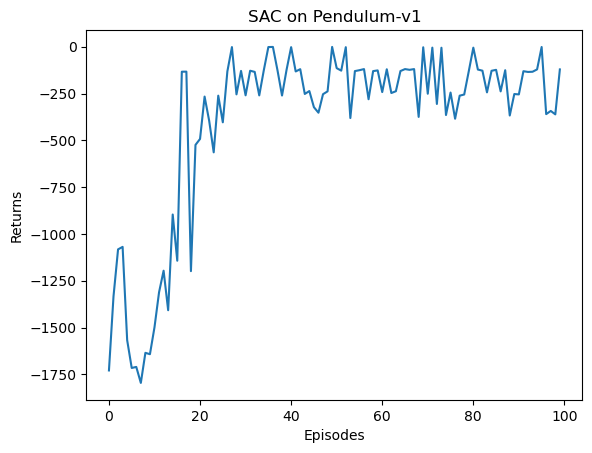

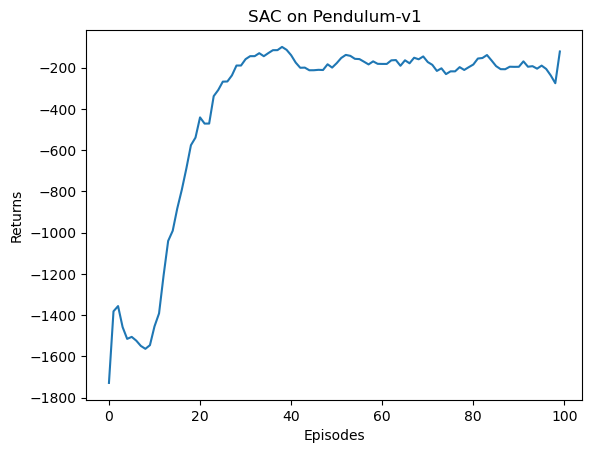

In [13]:
episodes_list = list(range(len(return_list)))
plt.plot(episodes_list, return_list)
plt.xlabel('Episodes')
plt.ylabel('Returns')
plt.title('SAC on {}'.format(env_name))
plt.show()

mv_return = rl_utils.moving_average(return_list, 9)
plt.plot(episodes_list, mv_return)
plt.xlabel('Episodes')
plt.ylabel('Returns')
plt.title('SAC on {}'.format(env_name))
plt.show()

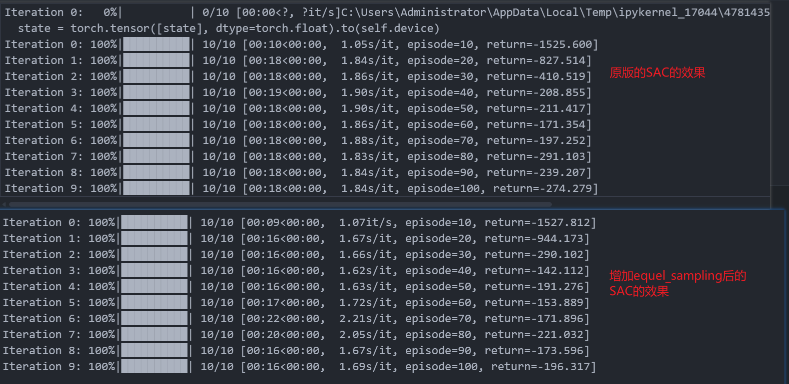